# Customer Churn Prediction

Predicting which telecom customers are likely to cancel their service, and estimating the revenue impact of acting on those predictions early.

**Dataset:** IBM Telco Customer Churn (7,043 customers, Kaggle)
**Goal:** Find out who's about to leave, why, and what it's worth to the business if we catch them in time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# TotalCharges is money, not text so converting it 

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

In [5]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [6]:
# only 11 missing rows out of 7043 - not worth imputing, just dropping them
df = df.dropna()

# customerID is a random ID, no predictive value, dropping it now so it doesn't accidentally
# end up in the model later
df = df.drop('customerID', axis=1)

print(df.shape)

(7032, 20)


In [7]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


**Insight :** ~26.5% of customers in this dataset have churned — roughly 1 in 4. This also tells us the classes are imbalanced (74/26), which matters later when we look at model metrics, not just accuracy.

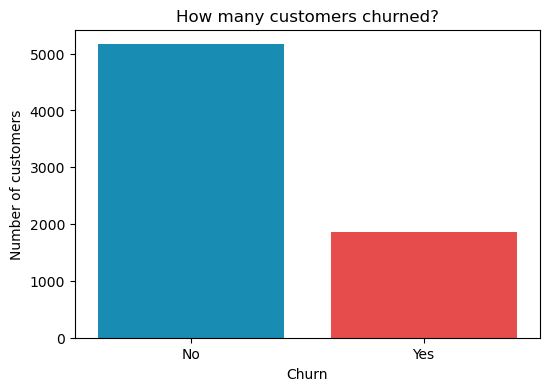

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['#0099CC','#FF3333'])
plt.title('How many customers churned?')
plt.xlabel('Churn')
plt.ylabel('Number of customers')
plt.show()

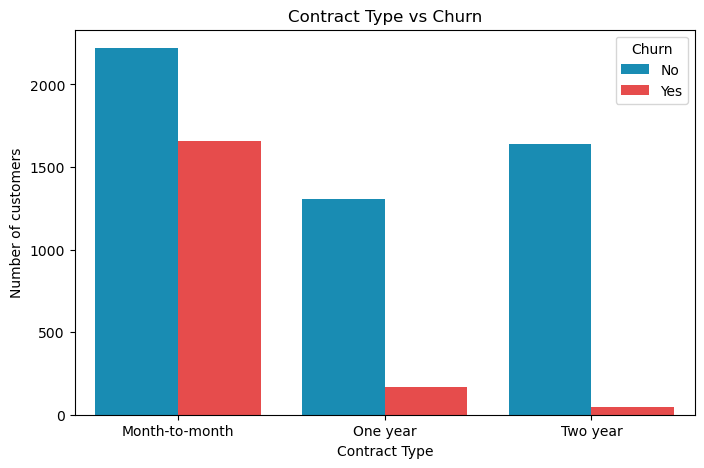

In [9]:
# does contract length actually keep people around? checking
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#0099CC','#FF3333'])
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of customers')
plt.show()

**Insight:** Month-to-month customers churn far more than 1-year or 2-year contract customers. Makes sense — no commitment means no friction to leave.

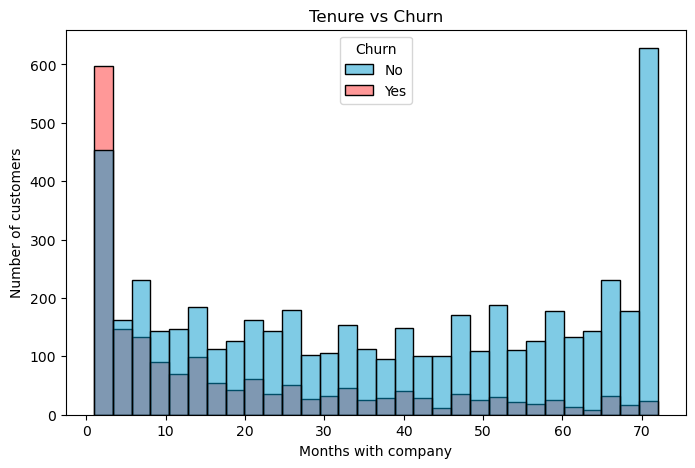

In [10]:
# do customers who just joined leave faster than long-time customers?
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['#0099CC','#FF3333'])
plt.title('Tenure vs Churn')
plt.xlabel('Months with company')
plt.ylabel('Number of customers')
plt.show()

**Insight :** Churn is heavily concentrated in the first few months. Once someone passes the ~2 year mark, they barely ever leave. This points to onboarding/early experience being the real risk window.

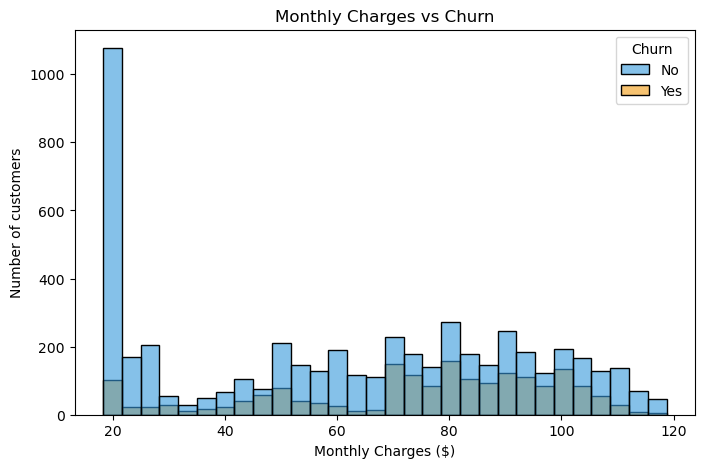

In [11]:
# higher bill = more likely to leave? testing that assumption
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30,
             palette={'No':'#3498DB', 'Yes':'#F39C12'}, alpha=0.6)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of customers')
plt.show()

In [12]:
# double-checking the chart with actual numbers, since charts can be misread
print(df.groupby('Churn')['MonthlyCharges'].describe())

        count       mean        std    min    25%    50%     75%     max
Churn                                                                   
No     5163.0  61.307408  31.094557  18.25  25.10  64.45  88.475  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.65  94.200  118.35


**Insight :** Churned customers pay $74/month on average vs $61 for loyal customers. Higher bills line up with higher churn — probably an expectations-vs-value problem.

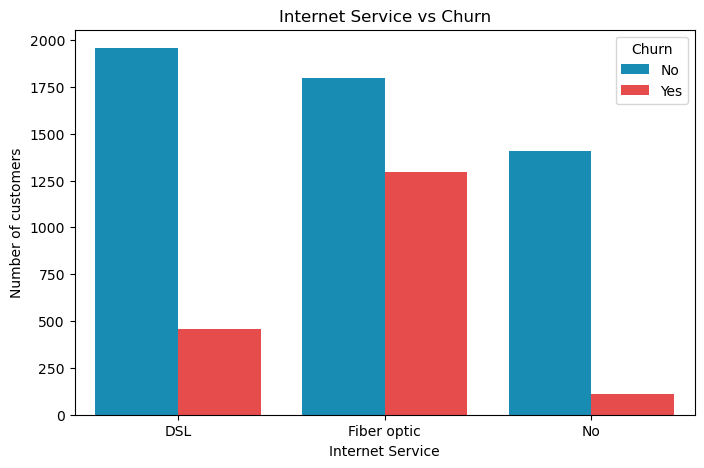

In [13]:
# fiber optic is the premium plan - does premium mean loyal, or does high price backfire?
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#0099CC','#FF3333'])
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Number of customers')
plt.show()

**Insight :** Fiber optic customers churn the most, even though it's the premium tier. Expensive + high expectations + any service hiccup = people leave. Customers with no internet service barely churn at all.

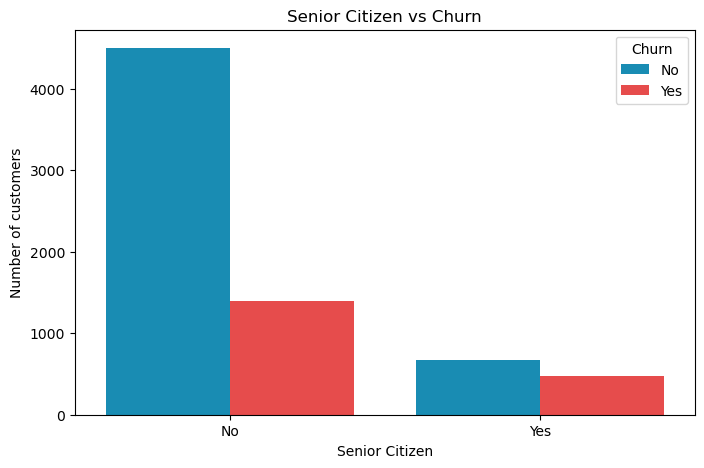

In [14]:
# SeniorCitizen is stored as 0/1, swapping to Yes/No just so the chart is readable
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: 'No', 1: 'Yes'})

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette=['#0099CC','#FF3333'])
plt.title('Senior Citizen vs Churn')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of customers')
plt.show()

In [15]:
# raw counts on this chart are misleading since there are way fewer seniors overall
# checking the actual rate instead of the raw bar height
print(df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True) * 100)

SeniorCitizen  Churn
No             No       76.349745
               Yes      23.650255
Yes            No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64


**Insight :** Seniors churn at ~42% vs ~24% for non-seniors — almost double the rate, even though the chart's raw bars look smaller for seniors (because there are fewer of them overall).

#### Feature Engineering

Creating two new columns that aren't directly in the data but should help the model:
- **AvgMonthlySpend** — TotalCharges divided by tenure. More reliable than MonthlyCharges alone since it reflects what they've actually paid on average over their whole relationship with the company, not just their current bill.
- **NumServices** — how many of the 8 add-on services a customer has. My hypothesis: more services = more invested in the company = harder to walk away from.

In [16]:
# converting SeniorCitizen back to 0/1 - changed it earlier only for the chart label
df['SeniorCitizen'] = df['SeniorCitizen'].map({'Yes': 1, 'No': 0})

In [17]:
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure']

service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = (df[service_cols] == 'Yes').sum(axis=1)

df[['AvgMonthlySpend', 'NumServices']].head()

,AvgMonthlySpend,NumServices
0,29.850000,1
1,55.573529,3
2,54.075000,3
3,40.905556,3
4,75.825000,1


In [18]:
# checking if the new NumServices feature actually says anything useful before trusting it
print(df.groupby('NumServices')['Churn'].value_counts(normalize=True) * 100)

NumServices  Churn
0            No       56.250000
             Yes      43.750000
1            No       78.845021
             Yes      21.154979
2            No       67.116358
             Yes      32.883642
3            No       63.523316
             Yes      36.476684
4            No       68.621064
             Yes      31.378936
5            No       74.392936
             Yes      25.607064
6            No       77.448071
             Yes      22.551929
7            No       87.594937
             Yes      12.405063
8            No       94.711538
             Yes       5.288462
Name: proportion, dtype: float64


**Insight:** Customers with 0 services churn at ~44%. Customers with all 8 services churn at only ~5%. This is one of the strongest patterns in the whole dataset — confirms the new feature is actually pulling its weight, not just noise.

In [19]:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity',
                  'OnlineBackup', 'DeviceProtection', 'TechSupport',
                  'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in yes_no_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [20]:
# Contract, InternetService, PaymentMethod, MultipleLines all have 3+ categories
# with no natural ranking, so one-hot encoding instead of plain numbers
# drop_first=True avoids creating a redundant column (if all other dummy cols are 0, that's the dropped category)
df = pd.get_dummies(df, columns=['MultipleLines', 'InternetService',
                                  'Contract', 'PaymentMethod'], drop_first=True)

df.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
OnlineSecurity                           float64
OnlineBackup                             float64
DeviceProtection                         float64
TechSupport                              float64
StreamingTV                              float64
StreamingMovies                          float64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
AvgMonthlySpend                          float64
NumServices                                int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fibe

In [21]:
# one-hot encoding leaves True/False columns - converting those to 1/0 too,
# everything needs to be numeric before this goes into a model
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

In [22]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [23]:
from sklearn.model_selection import train_test_split

# holding back 20% of the data the model never sees during training, to test it honestly later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 26)
Testing data: (1407, 26)




**Decision Tree → Random Forest → XGBoost**



In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [25]:
# baseline model - simplest possible tree-based classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7356076759061834


In [26]:
# random forest = many decision trees voting together, usually more stable than one tree alone
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7896233120113717


In [27]:
# xgboost builds trees sequentially, each new tree correcting the previous one's mistakes
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGBoost (default) Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost (default) Accuracy: 0.7739872068230277


In [28]:
# default xgboost barely beat random forest, so tuning a few key settings
# n_estimators: more trees to learn from
# max_depth: kept shallow on purpose to avoid overfitting
# learning_rate: slower learning, usually gives better generalization than the default
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGBoost (tuned) Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost (tuned) Accuracy: 0.7903340440653873


In [29]:
print("Decision Tree  :", accuracy_score(y_test, dt_pred))
print("Random Forest  :", accuracy_score(y_test, rf_pred))
print("XGBoost Tuned  :", accuracy_score(y_test, xgb_pred))

Decision Tree  : 0.7356076759061834
Random Forest  : 0.7896233120113717
XGBoost Tuned  : 0.7903340440653873


#### Why accuracy alone isn't enough?


Accuracy looked fine at ~79%, but the dataset is imbalanced (74% No / 26% Yes), so a model that just guessed "No churn" every single time would already score ~74% without learning anything useful. Needed to actually check how well it identifies the customers who churn, not just overall correctness.

In [30]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



**The real problem:** recall for churners (class 1) was only **0.50** — meaning the model was missing half the customers who actually left. For a churn project, that's the one number that actually matters to the business, and it was the weak point.



In [31]:
# default cutoff is 50% probability = churn. lowering it to 30% makes the model
# flag a customer as at-risk even when it's only moderately confident,
# trading some precision for a meaningful recall gain
y_pred_adjusted = (xgb_model.predict_proba(X_test)[:, 1] >= 0.3).astype(int)
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.75      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



**Result:** recall for churners jumped from 50% → 75% (now catching 3 out of 4 actual churners), at the cost of precision dropping from 63% → 51% (more false alarms). For a retention use case this is the right tradeoff — a wasted discount offer costs far less than losing a customer outright.

####  Business impact

This is the part that actually matters to a business, not just a model metric. Translating "75% recall" into an actual dollar figure.

In [32]:
high_risk_customers = X_test[y_pred_adjusted == 1]
print("Number of high risk customers:", len(high_risk_customers))

Number of high risk customers: 549


In [33]:
revenue_at_risk = high_risk_customers['MonthlyCharges'].sum()
print("Monthly revenue at risk: $", round(revenue_at_risk, 2))

Monthly revenue at risk: $ 41374.75


In [34]:
# 35% is a realistic retention campaign success rate, not every flagged customer
# will actually be saved by a discount/offer - being conservative here on purpose
retention_rate = 0.35
revenue_saved = revenue_at_risk * retention_rate
print("Potential monthly revenue saved: $", round(revenue_saved, 2))

Potential monthly revenue saved: $ 14481.16


In [35]:
annual_savings = revenue_saved * 12
print("Potential annual revenue saved: $", round(annual_savings, 2))

Potential annual revenue saved: $ 173773.95


**Bottom line:** on the held-out test set alone, this model flags 549 at-risk customers worth ~$41K/month. Assuming a realistic 35% retention success rate, that's roughly **$173K in potential annual savings** if the business acts on these predictions.



###  Saving the model

Saving the trained model and the exact column structure it expects, so the Streamlit dashboard can load it without retraining every time.

In [36]:
import joblib

joblib.dump(xgb_model, 'churn_model.pkl')

['churn_model.pkl']

In [37]:
model_columns = X_train.columns.tolist()
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

## Summary

| Step | Result |
|---|---|
| Dataset | 7,032 customers (after cleaning), 26 features |
| Best model | XGBoost (tuned), threshold adjusted to 0.3 |
| Recall (churners) | 75% |
| High-risk customers flagged | 549 (on test set) |
| Potential annual savings | ~$173,773 |

A live dashboard built on this model (`app.py`, Streamlit) lets anyone upload raw customer data and get churn risk scores plus an automatic business impact estimate.